In [ ]:
# Load raw crime data



import pandas as pd

crime_path = r"C:\Users\USER\Downloads\crim_off_cat$defaultview_spreadsheet.xlsx"

crime_raw = pd.read_excel(crime_path, header=None)

crime_raw.head(20)

c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,Data extracted on 12/04/2026 20:11:42 from [ES...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Dataset:,Police-recorded offences by offence category [...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Last updated:,23/04/2024 23:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Time frequency,NaN,Annual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,International classification of crime for stat...,NaN,Intentional homicide,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Unit of measure,NaN,Number,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,TIME,2014,NaN,2015,NaN,2016,NaN,2017,NaN,2018,NaN,2019,NaN,2020,NaN,2021,NaN,2022,NaN,2023
9,GEO (Labels),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
# check where the data starts from


crime_data = crime_raw.iloc[10:].copy()

crime_data.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
10,Belgium,210,NaN,231,NaN,175,NaN,198,NaN,192,NaN,147,NaN,149,NaN,157,NaN,185,NaN,162
11,Bulgaria,112,NaN,126,NaN,79,NaN,95,NaN,92,NaN,81,NaN,67,NaN,89,NaN,76,NaN,74
12,Czechia,81,NaN,88,NaN,65,NaN,40,NaN,55,NaN,81,NaN,57,NaN,46,NaN,79,NaN,68
13,Denmark,62,NaN,52,NaN,53,NaN,61,NaN,54,NaN,54,NaN,51,NaN,42,NaN,59,NaN,53
14,Germany,645,NaN,655,NaN,747,NaN,738,NaN,632,NaN,586,NaN,719,NaN,631,NaN,614,NaN,661


In [34]:
# Select Column


crime_data.iloc[:5, :10]

,0,1,2,3,4,5,6,7,8,9
10,Belgium,210,NaN,231,NaN,175,NaN,198,NaN,192
11,Bulgaria,112,NaN,126,NaN,79,NaN,95,NaN,92
12,Czechia,81,NaN,88,NaN,65,NaN,40,NaN,55
13,Denmark,62,NaN,52,NaN,53,NaN,61,NaN,54
14,Germany,645,NaN,655,NaN,747,NaN,738,NaN,632


In [ ]:

# Remove empty columns


cols = [0] + list(range(1, crime_data.shape[1], 2))

crime_data = crime_data.iloc[:, cols]

crime_data.head()

,0,1,3,5,7,9,11,13,15,17,19
10,Belgium,210,231,175,198,192,147,149,157,185,162
11,Bulgaria,112,126,79,95,92,81,67,89,76,74
12,Czechia,81,88,65,40,55,81,57,46,79,68
13,Denmark,62,52,53,61,54,54,51,42,59,53
14,Germany,645,655,747,738,632,586,719,631,614,661


In [ ]:
# We extract year values 

years = crime_raw.iloc[8].dropna().tolist()
years = [y for y in years if str(y).strip() != "TIME"]
print(years)

['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']


In [45]:
# Match years to column


years_correct = years[:crime_data.shape[1] - 1]

print("Number of value columns:", crime_data.shape[1] - 1)
print("Number of years:", len(years_correct))
print(years_correct)

Number of value columns: 10
Number of years: 10
['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']


In [46]:
# Assign ccorrect column names using years earlier extracted.


crime_data.columns = ["Country"] + years_correct
crime_data.head()

,Country,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
10,Belgium,210,231,175,198,192,147,149,157,185,162
11,Bulgaria,112,126,79,95,92,81,67,89,76,74
12,Czechia,81,88,65,40,55,81,57,46,79,68
13,Denmark,62,52,53,61,54,54,51,42,59,53
14,Germany,645,655,747,738,632,586,719,631,614,661


In [47]:
# We reshape the data so each row represents one country in one year

crime_long = crime_data.melt(id_vars="Country", var_name="Year", value_name="Crime")
crime_long.head()

,Country,Year,Crime
0,Belgium,2014,210
1,Bulgaria,2014,112
2,Czechia,2014,81
3,Denmark,2014,62
4,Germany,2014,645


In [48]:
# Importing population data - 2nd Data


pop_path = r"C:\Users\USER\Downloads\demo_pjan$defaultview_spreadsheet.xlsx"

pop_raw = pd.read_excel(pop_path, header=None)

pop_raw.head(20)

c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,Data extracted on 12/04/2026 20:14:42 from [ES...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Dataset:,Population on 1 January by age and sex [demo_p...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Last updated:,09/04/2026 23:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Time frequency,NaN,Annual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Unit of measure,NaN,Number,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Age class,NaN,Total,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Sex,NaN,Total,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,TIME,2016,NaN,2017,NaN,2018,NaN,2019,NaN,2020,...,2021,NaN,2022,NaN,2023,NaN,2024,NaN,2025,NaN


In [49]:
# Inspect data structure

pop_raw.iloc[8:20, :5]

,0,1,2,3,4
8,NaN,NaN,NaN,NaN,NaN
9,TIME,2016,NaN,2017,NaN
10,GEO (Labels),NaN,NaN,NaN,NaN
11,European Union - 27 countries (from 2020),444003268,e,444670605,be
12,European Union - 28 countries (2013-2020),509382312,e,510514747,be
13,European Union - 27 countries (2007-2013),505251197,e,506435978,be
14,Euro area – 21 countries (from 2026),:,NaN,:,NaN
15,Euro area – 20 countries (2023-2025),343444952,NaN,344141575,b
16,Belgium,11311117,NaN,11351727,NaN
17,Bulgaria,6938759,NaN,6849518,NaN


In [50]:
# Extract the real data from Belgium

pop_data = pop_raw.iloc[11:].copy()

pop_data.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
11,European Union - 27 countries (from 2020),444003268,e,444670605,be,445301376,e,446149924,NaN,447030024,...,445891011,bep,445972024,ep,447695350,bep,449306184,ep,450646971,ep
12,European Union - 28 countries (2013-2020),509382312,e,510514747,be,511574952,e,512797036,NaN,514055566,...,:,NaN,:,NaN,:,NaN,:,NaN,:,NaN
13,European Union - 27 countries (2007-2013),505251197,e,506435978,be,507560611,e,508828360,NaN,510122055,...,:,NaN,:,NaN,:,NaN,:,NaN,:,NaN
14,Euro area – 21 countries (from 2026),:,NaN,:,NaN,:,NaN,:,NaN,:,...,:,NaN,:,NaN,:,NaN,:,NaN,358076879,p
15,Euro area – 20 countries (2023-2025),343444952,NaN,344141575,b,344808648,NaN,345712139,NaN,346640106,...,346718238,NaN,347104468,NaN,348557873,bp,350174019,p,351639519,p


In [ ]:
# We remove non-country rows like EU totals and Euro area before doing anything else.


pop_data = pop_raw.iloc[11:].copy()

pop_data = pop_data[
    ~pop_data.iloc[:, 0].str.contains("European|Euro area", na=False)
]

pop_data.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
16,Belgium,11311117,NaN,11351727,NaN,11398589,NaN,11455519,NaN,11522440,...,11554767,NaN,11617623,NaN,11742796,NaN,11817096,NaN,11883495,NaN
17,Bulgaria,6938759,NaN,6849518,NaN,6757418,NaN,6664177,NaN,6569275,...,6532117,NaN,6482484,NaN,6447710,NaN,6445481,NaN,6437360,NaN
18,Czechia,10553843,NaN,10578820,NaN,10610055,NaN,10649800,NaN,10693939,...,10494836,b,10516707,NaN,10827529,NaN,10900555,NaN,10909500,NaN
19,Denmark,5707251,NaN,5748769,NaN,5781190,NaN,5806081,NaN,5822763,...,5840045,NaN,5873420,NaN,5932654,NaN,5961249,NaN,5992734,NaN
20,Germany,82175684,NaN,82521653,NaN,82792351,NaN,83019213,NaN,83166711,...,83155031,NaN,83237124,NaN,83118501,b,83456045,NaN,83577140,NaN


In [ ]:
# Keep only the real population value columns

cols = [0] + list(range(1, pop_data.shape[1], 2))

pop_data = pop_data.iloc[:, cols]

pop_data.head()

,0,1,3,5,7,9,11,13,15,17,19
16,Belgium,11311117,11351727,11398589,11455519,11522440,11554767,11617623,11742796,11817096,11883495
17,Bulgaria,6938759,6849518,6757418,6664177,6569275,6532117,6482484,6447710,6445481,6437360
18,Czechia,10553843,10578820,10610055,10649800,10693939,10494836,10516707,10827529,10900555,10909500
19,Denmark,5707251,5748769,5781190,5806081,5822763,5840045,5873420,5932654,5961249,5992734
20,Germany,82175684,82521653,82792351,83019213,83166711,83155031,83237124,83118501,83456045,83577140


In [ ]:
# Rename columns

pop_data.columns = ["Country", "2010", "2012", "2014", "2016", "2018", "2020", "2021", "2022", "2023", "2024"]

In [55]:
# Set Country as Index

pop_data.set_index("Country", inplace=True)

In [ ]:
# Convert to numbers and check for missing values

pop_data = pop_data.apply(pd.to_numeric, errors='coerce')
pop_data.isna().sum()

2010    409
2012    409
2014    394
2016    394
2018    438
2020    439
2021    454
2022    481
2023    469
2024    469
dtype: int64

In [ ]:
# remove missing values

pop_data = pop_data.dropna(how='all')
pop_data.isna().sum()

2010    0
2012    0
2014    0
2016    0
2018    0
2020    0
2021    0
2022    0
2023    0
2024    0
dtype: int64

In [68]:
# Filter data set to only include EU countries

eu_countries = [
    "Austria", "Belgium", "Bulgaria", "Croatia", "Cyprus", "Czechia",
    "Denmark", "Estonia", "Finland", "France", "Germany", "Greece",
    "Hungary", "Ireland", "Italy", "Latvia", "Lithuania", "Luxembourg",
    "Malta", "Netherlands", "Poland", "Portugal", "Romania", "Slovakia",
    "Slovenia", "Spain", "Sweden"
]
pop_eu = pop_data.loc[pop_data.index.isin(eu_countries)]
pop_eu.shape

(405, 10)

In [70]:
# making sure both datasets use the same country names

print(crime_data.index[:10])
print(pop_eu.index[:10])

RangeIndex(start=10, stop=20, step=1)
Index(['Belgium', 'Bulgaria', 'Czechia', 'Denmark', 'Germany', 'Estonia',
       'Ireland', 'Greece', 'Spain', 'France'],
      dtype='str', name='Country')


In [76]:
# inspect  and align both data set

crime_data.head()
print(crime_data.columns)
print(crime_data.index[:10])
common_countries = crime_data.index.intersection(pop_eu.index)

crime_eu = crime_data.loc[common_countries].copy()
pop_eu_aligned = pop_eu.loc[common_countries].copy()
print(len(common_countries))
print(common_countries)


Index(['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023'],
      dtype='str')
Index(['Belgium', 'Bulgaria', 'Czechia', 'Denmark', 'Germany', 'Estonia',
       'Ireland', 'Greece', 'Spain', 'France'],
      dtype='str', name='Country')
27
Index(['Belgium', 'Bulgaria', 'Czechia', 'Denmark', 'Germany', 'Estonia',
       'Ireland', 'Greece', 'Spain', 'France', 'Croatia', 'Italy', 'Cyprus',
       'Latvia', 'Lithuania', 'Luxembourg', 'Hungary', 'Malta', 'Netherlands',
       'Austria', 'Poland', 'Portugal', 'Romania', 'Slovenia', 'Slovakia',
       'Finland', 'Sweden'],
      dtype='str', name='Country')


In [ ]:
# baseline ranking

# Group by country and SUM all crime values for 2023
crime_2023_clean = crime_eu.groupby(level=0)["2023"].sum()

# After:
# Now each country has ONE total crime value for 2023

# Create ranking again
raw_ranking = crime_2023_clean.sort_values(ascending=False)

ranking_table = raw_ranking.reset_index()
ranking_table.columns = ["Country", "Raw Crime Value"]
ranking_table["Raw Rank"] = range(1, len(ranking_table) + 1)

ranking_table


,Country,Raw Crime Value,Raw Rank
0,France,1541481.37,1
1,Germany,1279847.94,2
2,Italy,896937.73,3
3,Sweden,331029.58,4
4,Spain,261447.58,5
5,Netherlands,256954.59,6
6,Belgium,230350.07,7
7,Denmark,174976.48,8
8,Finland,141490.08,9
9,Austria,122343.13,10


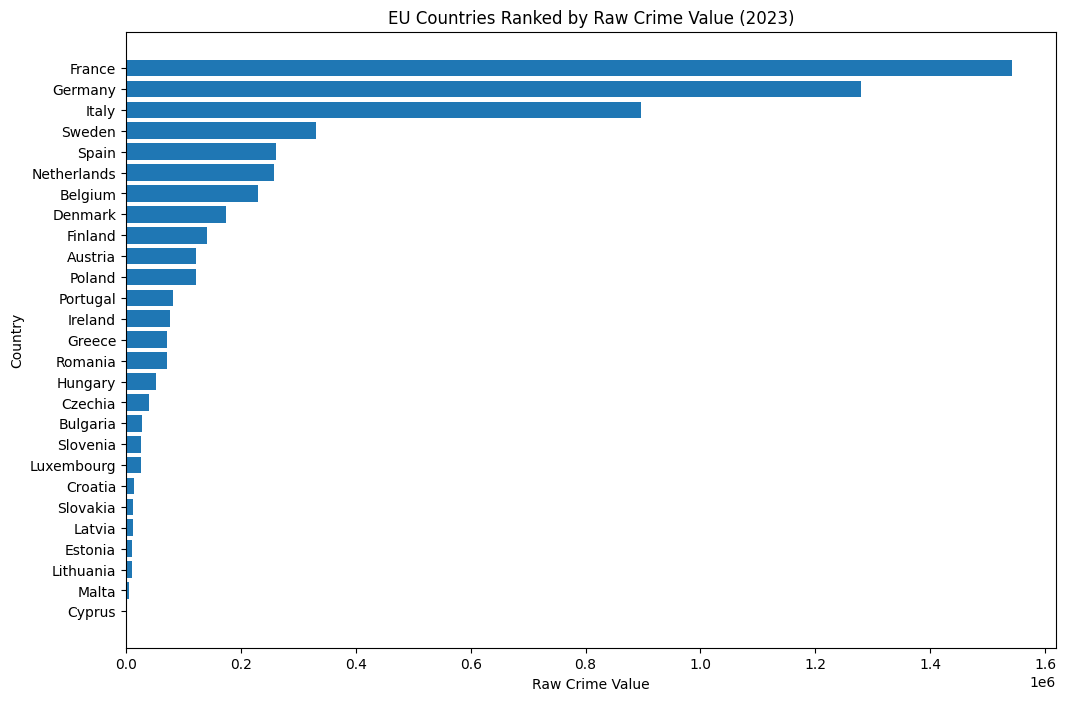

In [84]:
# Before:
# This chart shows the usual ranking method: total crime only.
# It is useful as the starting point we want to critique.

import matplotlib.pyplot as plt

ranking_plot = ranking_table.sort_values("Raw Rank")

plt.figure(figsize=(12, 8))
plt.barh(ranking_plot["Country"], ranking_plot["Raw Crime Value"])
plt.gca().invert_yaxis()
plt.title("EU Countries Ranked by Raw Crime Value (2023)")
plt.xlabel("Raw Crime Value")
plt.ylabel("Country")
plt.show()



This chart ranks countries based on total crime. However, it does not consider population size. Larger countries naturally report more crimes simply because they have more people. As a result, this ranking may give a misleading impression of danger.”

In [ ]:
# 1st suggesting - using per capita - LENS 1
# pop_eu_aligned likely has duplicate country labels, so assigning Population_2023 fails.
# We fix that by creating ONE population value per country for 2023.

# Check whether population index has duplicates
print(pop_eu_aligned.index.duplicated().sum())

# Build a clean 2023 population series with one row per country
pop_2023_clean = pop_eu_aligned.groupby(level=0)["2023"].first()

# Optional check: this should now be unique
print(pop_2023_clean.index.is_unique)

# Rebuild the comparison table from the raw ranking
comparison_table = ranking_table.copy().set_index("Country")

# Attach clean population data
comparison_table["Population_2023"] = pop_2023_clean

# Calculate crime per 100,000 people
comparison_table["Crime_per_100k"] = (
    comparison_table["Raw Crime Value"] / comparison_table["Population_2023"]
) * 100000

# Create a new rank based on the per-capita crime value
comparison_table["PerCapita Rank"] = (
    comparison_table["Crime_per_100k"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

# Sort by the new rank so we can compare properly
comparison_table = comparison_table.sort_values("PerCapita Rank")

comparison_table

378
True


,Raw Crime Value,Raw Rank,Population_2023,Crime_per_100k,PerCapita Rank
Country,,,,,
Luxembourg,26161.67,20,672050.0,3892.816011,1
Sweden,331029.58,4,10551707.0,3137.213533,2
Denmark,174976.48,8,5961249.0,2935.231862,3
Finland,141490.08,9,5603851.0,2524.872271,4
France,1541481.37,1,68669303.0,2244.789597,5
Belgium,230350.07,7,11817096.0,1949.295072,6
Germany,1279847.94,2,83456045.0,1533.559301,7
Italy,896937.73,3,58971230.0,1520.975109,8
Ireland,76699.93,13,5351681.0,1433.193234,9


When crime is adjusted for population, the ranking changes significantly. Countries that appear dangerous based on total crime are not necessarily the most risky per person. This shows that ranking alone can be misleading.

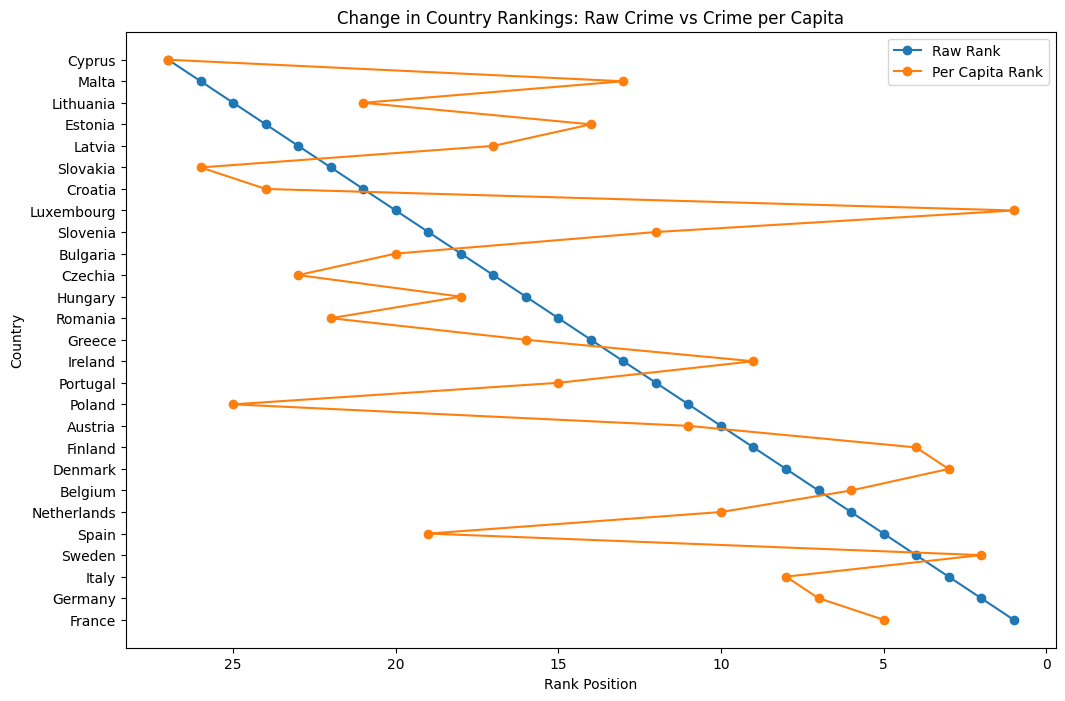

In [86]:


# We rebuild the clean comparison table from comparison_table

# We want to visually compare how rankings change
# between raw crime and per capita crime.

final_table = comparison_table.reset_index()

final_table = final_table[
    ["Country", "Raw Rank", "PerCapita Rank", "Raw Crime Value", "Crime_per_100k"]
]

# Sort by Raw Rank so we keep the original order
final_table = final_table.sort_values("Raw Rank")

final_table

import matplotlib.pyplot as plt

plot_data = final_table.copy()

# Sort by Raw Rank so we see the original ranking order
plot_data = plot_data.sort_values("Raw Rank")

plt.figure(figsize=(12, 8))

plt.plot(plot_data["Raw Rank"], plot_data["Country"], 'o-', label="Raw Rank")
plt.plot(plot_data["PerCapita Rank"], plot_data["Country"], 'o-', label="Per Capita Rank")

plt.xlabel("Rank Position")
plt.ylabel("Country")
plt.title("Change in Country Rankings: Raw Crime vs Crime per Capita")
plt.legend()

plt.gca().invert_xaxis()
plt.show()



This graph demonstrates that:

Ranking countries based only on total crime can be misleading, because it ignores population size. When crime is adjusted per person, the ranking changes substantially, showing that total crime does not accurately reflect actual risk.

In [ ]:
# LENS 2 - ANY CHANGE AMONGST THE COUNTRIES?
# We clean all year columns first so aggregation and trend calculation will work.

year_cols = [str(year) for year in range(2014, 2024)]

for col in year_cols:
    crime_eu[col] = (
        crime_eu[col]
        .astype(str)
        .str.strip()
        .str.replace(",", "", regex=False)
        .replace(":", pd.NA)
    )
    crime_eu[col] = pd.to_numeric(crime_eu[col], errors="coerce")

# Now aggregate total crime per country for each year
crime_total = crime_eu.groupby(level=0)[year_cols].sum()

# Calculate trend from 2014 to 2023
trend_table = crime_total.copy()
trend_table["Trend_%"] = (
    (trend_table["2023"] - trend_table["2014"]) /
    trend_table["2014"].replace(0, pd.NA)
) * 100

# Keep only the trend column and sort it
trend_table = trend_table[["Trend_%"]].sort_values("Trend_%", ascending=False)

trend_table

,Trend_%
Country,
Luxembourg,100.188162
Greece,37.175126
Spain,25.797552
France,3.154405
Belgium,2.634834
Croatia,-2.584878
Finland,-2.992244
Ireland,-7.762840
Cyprus,-7.772419


The trend analysis provides an important second layer of insight that further challenges the reliability of simple crime rankings.

While the ranking approach presents crime as a static snapshot, this table demonstrates that crime across EU countries is dynamic and evolving over time. Countries are not fixed in their levels of risk; instead, they are either improving or deteriorating.

A key observation is that several countries exhibit significant increases in crime over the period, such as Luxembourg (+100.19%), Greece (+37.18%), and Spain (+25.80%). This suggests that even if a country is not ranked at the top in terms of total crime, it may still represent a growing concern due to its upward trajectory.

Conversely, many countries show substantial decreases in crime, including Czechia (-63.56%), Lithuania (-63.27%), Slovakia (-58.82%), and Romania (-58.07%). These countries may appear in mid or lower positions in a ranking, but the trend indicates that their situation is improving significantly over time.

This contrast highlights a fundamental limitation of ranking:

Ranking treats countries as fixed positions, while in reality they are moving in different directions.

A country ranked highly based on current crime levels may actually be becoming safer, while another country with a lower ranking may be experiencing increasing crime. Therefore, ranking alone fails to capture whether risk is increasing, decreasing, or stable.

When combined with the population-adjusted analysis, the trend results reinforce a broader conclusion:

Population shows that ranking is structurally biased
Trend shows that ranking is temporally incomplete

Together, they demonstrate that:

A single ranking cannot adequately represent crime across countries because it ignores both scale (population) and direction (trend).

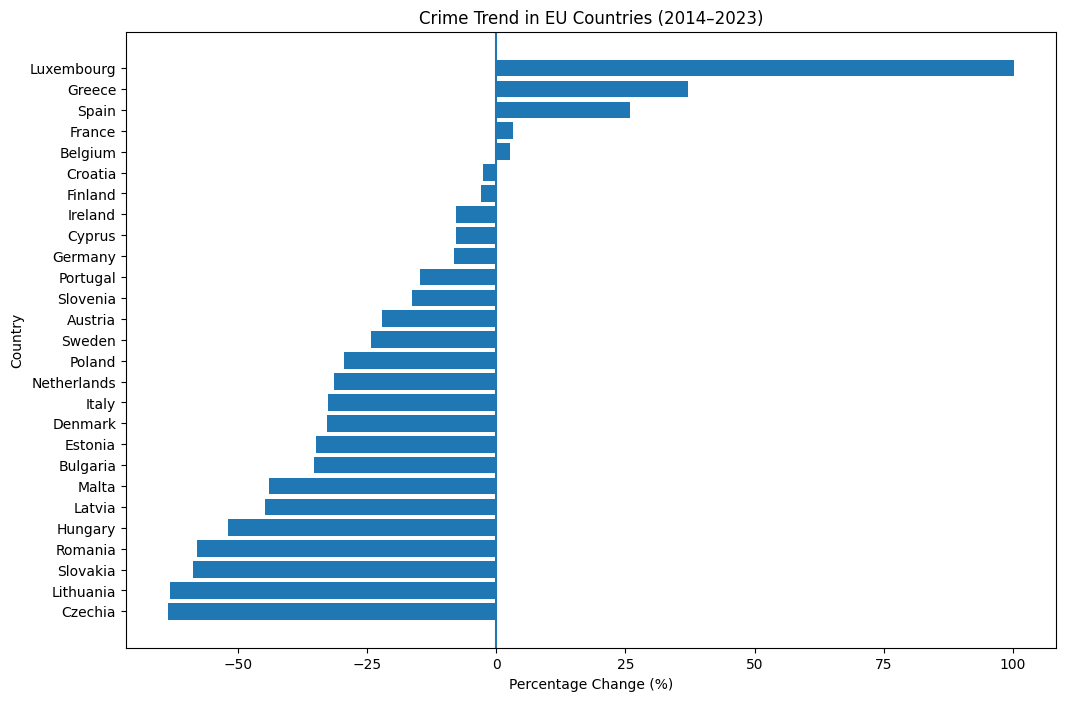

In [90]:

# We want to visualize how crime has changed over time.
# Positive values = increasing crime
# Negative values = decreasing crime

import matplotlib.pyplot as plt

plot_trend = trend_table.reset_index()

plt.figure(figsize=(12, 8))

plt.barh(plot_trend["Country"], plot_trend["Trend_%"])

plt.axvline(0)  # This line separates increase vs decrease

plt.title("Crime Trend in EU Countries (2014–2023)")
plt.xlabel("Percentage Change (%)")
plt.ylabel("Country")

plt.gca().invert_yaxis()
plt.show()



In [91]:
# Before:
# We combine everything into one table
# This becomes the foundation of your "profiling instead of ranking"

profile_table = final_table.copy()

# Add trend data
profile_table = profile_table.set_index("Country")
profile_table["Trend_%"] = trend_table["Trend_%"]

# Reset index
profile_table = profile_table.reset_index()

profile_table

,Country,Raw Rank,PerCapita Rank,Raw Crime Value,Crime_per_100k,Trend_%
0,France,1,5,1541481.37,2244.789597,3.154405
1,Germany,2,7,1279847.94,1533.559301,-8.217213
2,Italy,3,8,896937.73,1520.975109,-32.510729
3,Sweden,4,2,331029.58,3137.213533,-24.323085
4,Spain,5,19,261447.58,537.740066,25.797552
5,Netherlands,6,10,256954.59,1432.064987,-31.470446
6,Belgium,7,6,230350.07,1949.295072,2.634834
7,Denmark,8,3,174976.48,2935.231862,-32.730507
8,Finland,9,4,141490.08,2524.872271,-2.992244
9,Austria,10,11,122343.13,1335.805978,-22.062952


This table shows that countries differ not only in crime levels, but also in risk per person and direction over time. A single ranking fails to capture these differences, and can therefore lead to misleading conclusions about safety.”

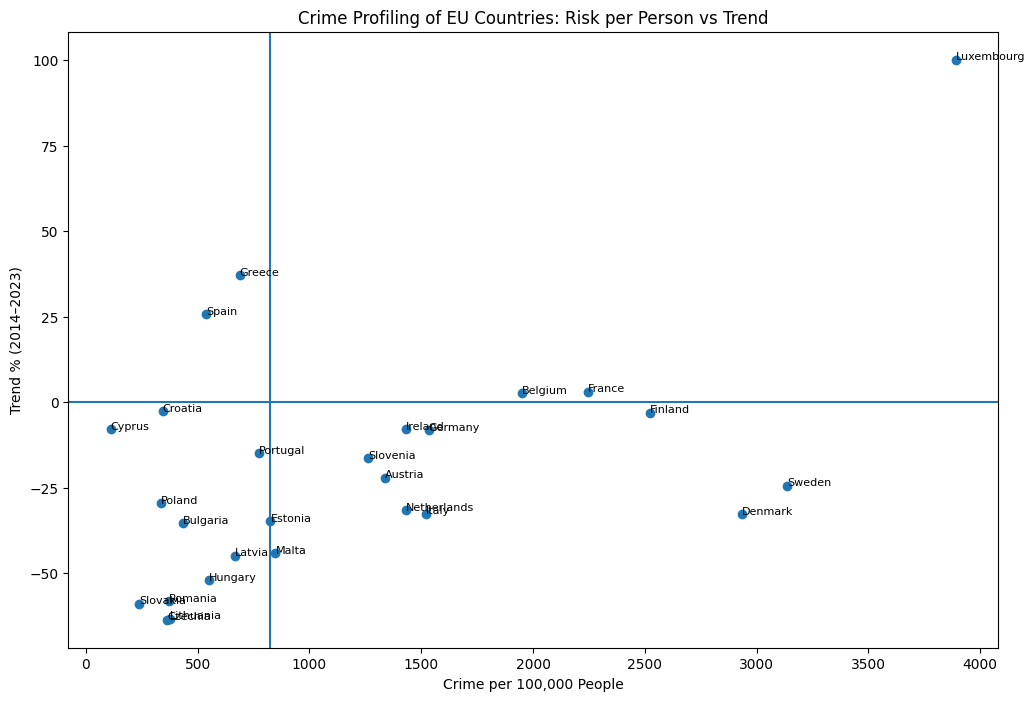

In [92]:
# Before:
# We are moving from ranking to profiling.
# This chart combines two lenses in one view:
# 1. Crime per 100,000 people (risk per person)
# 2. Trend % (whether crime is rising or falling)
#
# Each point is one country.

import matplotlib.pyplot as plt

scatter_data = profile_table.copy()

plt.figure(figsize=(12, 8))
plt.scatter(scatter_data["Crime_per_100k"], scatter_data["Trend_%"])

# Add country labels
for _, row in scatter_data.iterrows():
    plt.text(row["Crime_per_100k"], row["Trend_%"], row["Country"], fontsize=8)

# Reference lines
plt.axhline(0)
plt.axvline(scatter_data["Crime_per_100k"].median())

plt.xlabel("Crime per 100,000 People")
plt.ylabel("Trend % (2014–2023)")
plt.title("Crime Profiling of EU Countries: Risk per Person vs Trend")
plt.show()



This visualization shows that crime patterns across EU countries are complex and cannot be accurately represented by simple rankings. While ranking suggests a linear hierarchy of safety, profiling reveals distinct categories of countries based on risk levels and trends. Some countries face high but declining crime, others have low but rising crime, and a few combine both high risk and rapid growth. This demonstrates that policy decisions and public perception should rely on multidimensional analysis rather than single-value rankings.